# Example of Exploratory Data Analysis and ML Modeling

In this notebook, we will walk through the key stages of a Data Science workflow using a housing dataset from King County. You have already seen some of the early steps in a previous lecture. This time, we will go further by building and evaluating machine learning models.

As a quick reminder, here is the Data Science lifecycle:

<center><img src="./assets/DS_LC.png" alt="drawing" width="500"/></center>

The goal is to implement the essential steps of a supervised machine learning workflow with the Python library scikit-learn.  

We will use the following methods:  
- feature engineering,
- train/test split,
- model training,
- hyperparameter optimization with grid search and cross-validation,
- and model evaluation.

To make the workflow more concrete, we will use the following fictional scenario:

**You have just landed your dream job as a data scientist at an innovative company near Seattle. Before you move, you want to understand the local housing market and estimate fair property values so you can negotiate with confidence.**

```mermaid
flowchart LR
    A[Raw housing data] --> B[Data preparation]
    B --> C[Exploratory data analysis]
    C --> D[Feature engineering]
    D --> E[Model training]
    E --> F[Evaluation and tuning]
    F --> G[Save the final model]
```


![](assets/seattle_skyline.jpg)
(<span>Photo by <a href="https://unsplash.com/@phoebezzf?utm_source=unsplash&amp;utm_medium=referral&amp;utm_content=creditCopyText">Zhifei Zhou</a> on <a href="https://unsplash.com/s/photos/seattle-skyline?utm_source=unsplash&amp;utm_medium=referral&amp;utm_content=creditCopyText">Unsplash</a></span>)

**Rather than relying on intuition alone, we will use data to support the house-hunting process. Our aim is to predict home prices in and around Seattle so that we can estimate a realistic property value before negotiating.**

## Business Understanding

Seattle is located in King County, which is shown on the map below. To keep commuting time manageable, we limit the property search to this area.



![](assets/king_county_districts.jpeg)

(Photo from King County [imap](https://gismaps.kingcounty.gov/iMap/))

For this project, we use a dataset that contains property sales in King County from May 2014 to May 2015.

Before building any model, it is important to understand what information the dataset contains. The table below summarizes the available columns:

| **Column name** | **Description** |
|---|---|
| `id` | Unique identifier for a house sale |
| `date` | Date of sale |
| `price` | Sale price of the house |
| `bedrooms` | Number of bedrooms |
| `bathrooms` | Number of bathrooms; `.5` indicates a toilet room without a shower |
| `sqft_living` | Interior living area in square feet |
| `sqft_lot` | Lot size in square feet |
| `floors` | Number of floors |
| `waterfront` | Whether the house has a waterfront view (`0` = no, `1` = yes) |
| `view` | Index from `0` to `4` indicating the quality of the view |
| `condition` | Index from `1` to `5` describing the condition of the property |
| `grade` | Index from `1` to `13` describing construction and design quality |
| `sqft_basement` | Basement area in square feet |
| `yr_built` | Year the house was built |
| `yr_renovated` | Year of the last renovation |
| `zipcode` | ZIP code of the property |
| `lat` | Latitude |
| `long` | Longitude |
| `sqft_living15` | Interior living area of the nearest 15 neighbors |
| `sqft_lot15` | Lot size of the nearest 15 neighbors |



## Importing the Libraries

First, we import the libraries we will need throughout the notebook.



In [82]:
# Data manipulation, visualization, and machine learning libraries.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [83]:
# Load the dataset with pandas
kc_data = pd.read_csv("data/King_County_House_prices_dataset.csv")

In [84]:
# Look at the first 5 rows of the dataset.
# This helps us confirm that the file was loaded correctly.
kc_data.head(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,10/13/2014,221900.0,3,1.00,1180,5650,1.0,NaN,0.0,...,7,1180,0.0,1955,0.0,98178,47.5112,-122.257,1340,5650
1,6414100192,12/9/2014,538000.0,3,2.25,2570,7242,2.0,0.0,0.0,...,7,2170,400.0,1951,1991.0,98125,47.7210,-122.319,1690,7639
2,5631500400,2/25/2015,180000.0,2,1.00,770,10000,1.0,0.0,0.0,...,6,770,0.0,1933,NaN,98028,47.7379,-122.233,2720,8062
3,2487200875,12/9/2014,604000.0,4,3.00,1960,5000,1.0,0.0,0.0,...,7,1050,910.0,1965,0.0,98136,47.5208,-122.393,1360,5000
4,1954400510,2/18/2015,510000.0,3,2.00,1680,8080,1.0,0.0,0.0,...,8,1680,0.0,1987,0.0,98074,47.6168,-122.045,1800,7503
5,7237550310,5/12/2014,1230000.0,4,4.50,5420,101930,1.0,0.0,0.0,...,11,3890,1530.0,2001,0.0,98053,47.6561,-122.005,4760,101930
6,1321400060,6/27/2014,257500.0,3,2.25,1715,6819,2.0,0.0,0.0,...,7,1715,?,1995,0.0,98003,47.3097,-122.327,2238,6819
7,2008000270,1/15/2015,291850.0,3,1.50,1060,9711,1.0,0.0,NaN,...,7,1060,0.0,1963,0.0,98198,47.4095,-122.315,1650,9711
8,2414600126,4/15/2015,229500.0,3,1.00,1780,7470,1.0,0.0,0.0,...,7,1050,730.0,1960,0.0,98146,47.5123,-122.337,1780,8113
9,3793500160,3/12/2015,323000.0,3,2.50,1890,6560,2.0,0.0,0.0,...,7,1890,0.0,2003,0.0,98038,47.3684,-122.031,2390,7570


## Data Preparation

After loading the data, we need a reliable overview of its quality and structure.
We will answer the following questions:

- How many house sales are included in the dataset?
- What data types are present (`int`, `float`, `object`)?
- Are there any missing values?
- How many distinct values does each variable contain?



**1.** How many house sales are included in the dataset?



In [85]:
kc_data.shape

(21597, 21)

Each row represents one house sale.

The dataset contains 21597 sales records.



**2.** What data types are present (`int`, `float`, `object`)?
Which values look surprising?


In [86]:
kc_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   date           21597 non-null  str    
 2   price          21597 non-null  float64
 3   bedrooms       21597 non-null  int64  
 4   bathrooms      21597 non-null  float64
 5   sqft_living    21597 non-null  int64  
 6   sqft_lot       21597 non-null  int64  
 7   floors         21597 non-null  float64
 8   waterfront     19221 non-null  float64
 9   view           21534 non-null  float64
 10  condition      21597 non-null  int64  
 11  grade          21597 non-null  int64  
 12  sqft_above     21597 non-null  int64  
 13  sqft_basement  21597 non-null  str    
 14  yr_built       21597 non-null  int64  
 15  yr_renovated   17755 non-null  float64
 16  zipcode        21597 non-null  int64  
 17  lat            21597 non-null  float64
 18  long           21

Our dataset contains 8 floating-point columns, 11 integer columns, and 2 object columns.
We would normally expect variables such as sizes, room counts, indexes, and geographic information to be stored as numeric values.

The `date` column is stored as text, which is reasonable at this stage, but `sqft_basement` is also stored as text. That is surprising.
When we inspect the data more closely, we can see why: the column contains a `?` value, so pandas cannot safely interpret the full column as numeric.



**3.** Are there any missing values?

We have missing values in the columns `waterfront`, `view`, and `yr_renovated`.
The largest share of missing values appears in `yr_renovated`.

We will need to decide how to handle each of these columns carefully, because different kinds of missing values call for different strategies.



**4.** How many distinct values does each variable contain?



In [87]:
kc_data.nunique()

id               21420
date               372
price             3622
bedrooms            12
bathrooms           29
sqft_living       1034
sqft_lot          9776
floors               6
waterfront           2
view                 5
condition            5
grade               11
sqft_above         942
sqft_basement      304
yr_built           116
yr_renovated        70
zipcode             70
lat               5033
long               751
sqft_living15      777
sqft_lot15        8682
dtype: int64

Interesting findings:

**1.** We have 21420 distinct house IDs, which suggests that up to 177 houses may have been sold more than once.

**2.** We observe 3622 distinct sale prices, so many properties were sold for the same price.

**3.** Although `grade` is defined on a scale from 1 to 13, only 11 distinct values appear in the dataset.

**4.** The houses in our dataset were built across 116 different years.



Next, we can look at the distribution of the variables in more detail.

`kc_data.describe()` reports the following summary statistics:
- **count**: number of non-missing values
- **mean**: arithmetic average
- **std**: standard deviation
- **min**: smallest observed value
- **25%**: first quartile
- **50%**: median
- **75%**: third quartile
- **max**: largest observed value

These values help us spot outliers, skewed distributions, and variables that may need additional cleaning or transformation.



In [88]:
kc_data.describe().round(2)

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.159700e+04,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,19221.00,21534.00,21597.00,21597.00,21597.00,21597.00,17755.00,21597.00,21597.00,21597.00,21597.00,21597.00
mean,4.580474e+09,540296.57,3.37,2.12,2080.32,15099.41,1.49,0.01,0.23,3.41,7.66,1788.60,1971.00,83.64,98077.95,47.56,-122.21,1986.62,12758.28
std,2.876736e+09,367368.14,0.93,0.77,918.11,41412.64,0.54,0.09,0.77,0.65,1.17,827.76,29.38,399.95,53.51,0.14,0.14,685.23,27274.44
min,1.000102e+06,78000.00,1.00,0.50,370.00,520.00,1.00,0.00,0.00,1.00,3.00,370.00,1900.00,0.00,98001.00,47.16,-122.52,399.00,651.00
25%,2.123049e+09,322000.00,3.00,1.75,1430.00,5040.00,1.00,0.00,0.00,3.00,7.00,1190.00,1951.00,0.00,98033.00,47.47,-122.33,1490.00,5100.00
50%,3.904930e+09,450000.00,3.00,2.25,1910.00,7618.00,1.50,0.00,0.00,3.00,7.00,1560.00,1975.00,0.00,98065.00,47.57,-122.23,1840.00,7620.00
75%,7.308900e+09,645000.00,4.00,2.50,2550.00,10685.00,2.00,0.00,0.00,4.00,8.00,2210.00,1997.00,0.00,98118.00,47.68,-122.12,2360.00,10083.00
max,9.900000e+09,7700000.00,33.00,8.00,13540.00,1651359.00,3.50,1.00,4.00,5.00,13.00,9410.00,2015.00,2015.00,98199.00,47.78,-121.32,6210.00,871200.00


Interesting findings:

**1.** The average sale price is $540,296. The most expensive house sold for $7,700,000, while the cheapest sold for $78,000.

**2.** Half of the houses have 3 bedrooms or fewer. The maximum value is 33 bedrooms, which immediately looks suspicious.

**3.** On average, each house has about 2.1 bathrooms per bedroom.

**4.** 75% of houses have 2 floors or fewer.

**5.** Only about 1% of the houses have a waterfront view. Because `waterfront` is binary, its mean can be interpreted as a proportion.

**6.** The oldest house in the dataset dates from 1900, while the newest dates from 2015.



We could extract many more insights from the summary table, but we have already identified a few issues that should be handled during data cleaning:

- missing values
- the `?` entry in `sqft_basement`
- the record with 33 bedrooms

The remaining distributions will be easier to interpret later with charts. For now, we will focus on cleaning the data.



**33 bedrooms**

The maximum bedroom count points to a property with 33 bedrooms but only 2 bathrooms.



In [89]:
# Display the row where the condition `bedrooms == 33` is true.
kc_data.query("bedrooms == 33")

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
15856,2402100895,6/25/2014,640000.0,33,1.75,1620,6000,1.0,0.0,0.0,...,7,1040,580.0,1947,0.0,98103,47.6878,-122.331,1330,4700


A house with 33 bedrooms, 2 bathrooms, and only 1,620 square feet is extremely unlikely. This record is probably a data-entry error, so we remove it from the dataset.



In [90]:
# Drop the implausible row.
kc_data.drop(15856, axis=0, inplace=True)

**`?` in `sqft_basement`**

From the output of `.info()`, we can see that `sqft_basement` is stored as an object rather than a numeric value. The reason is that at least one row contains `?` instead of a number.

We will reconstruct the basement size as `sqft_living - sqft_above`.



In [91]:
# Recalculate `sqft_basement` as `sqft_living - sqft_above`.
kc_data["sqft_basement"] = kc_data["sqft_living"] - kc_data["sqft_above"]

**Missing values**


In [92]:
# Count missing values and calculate their percentage.
missing_values = kc_data.isnull().sum().to_frame(name="count")
missing_values["percentage"] = (missing_values["count"] / kc_data.shape[0] * 100).round(
    2
)
missing_values.query("count != 0")

,count,percentage
waterfront,2376,11.00
view,63,0.29
yr_renovated,3842,17.79


After replacing the invalid basement entries, three variables still contain missing values:

- `waterfront`: 2376 missing values (11.00%)
- `view`: 63 missing values (0.29%)
- `yr_renovated`: 3842 missing values (17.79%)

The `view` column has very few missing values, and the value 0 is by far the most common category. Because of that strong imbalance, replacing the missing values with 0 is a reasonable simplification here.



In [93]:
# Display the frequency of each value.
kc_data["view"].value_counts()

view
0.0    19421
2.0      957
3.0      508
1.0      330
4.0      317
Name: count, dtype: int64

In [94]:
# Replace missing values in `view` with the most frequent value (0).
kc_data["view"] = kc_data["view"].fillna(0)

The `waterfront` column shows a similar pattern, so we again replace the missing values with 0.



In [95]:
# Display the frequency of each value.
kc_data["waterfront"].value_counts()

waterfront
0.0    19074
1.0      146
Name: count, dtype: int64

In [96]:
# Replace missing values in `waterfront` with the most frequent value (0).
kc_data["waterfront"] = kc_data["waterfront"].fillna(0)

In [97]:
# Inspect the missing data again.
missing_values = kc_data.isnull().sum().to_frame(name="count")
missing_values["percentage"] = missing_values["count"] / kc_data.shape[0] * 100
missing_values.query("count != 0")

,count,percentage
yr_renovated,3842,17.790332


Because `yr_renovated` has a relatively large number of missing values, we do not simply fill it with a single constant. Instead, we combine `yr_built` and `yr_renovated` into a new feature called `last_known_change`, then remove the original two columns.



In [98]:
# Create an empty list to store the derived values.
last_known_change = []

# Inspect the `yr_renovated` value for each row.
for idx, yr_re in kc_data["yr_renovated"].items():
    # If `yr_renovated` is 0 or missing, use the original build year instead.
    if str(yr_re) == "nan" or yr_re == 0.0:
        last_known_change.append(kc_data["yr_built"][idx])
    # Otherwise, keep the renovation year in the new list.
    else:
        last_known_change.append(int(yr_re))

In [99]:
# Create a new column from the values collected above.
kc_data["last_known_change"] = last_known_change

In [100]:
# Drop the original `yr_renovated` and `yr_built` columns.
kc_data.drop("yr_renovated", axis=1, inplace=True)
kc_data.drop("yr_built", axis=1, inplace=True)

At this point, the main data cleaning steps are complete.

Commands such as `.describe()` already gave us a quick statistical overview, but exploratory data analysis becomes much easier once we visualize the distributions directly.



## Exploratory Data Analysis

Now we move from cleaning to exploration.
Histograms are a useful first step because they show how each variable is distributed and whether a variable behaves more like a continuous measure or a category.



In [101]:
# Select variables for a closer visual inspection.
columns_histogram = [
    "price",
    "bathrooms",
    "bedrooms",
    "floors",
    "grade",
    "last_known_change",
    "sqft_living",
    "sqft_lot",
]

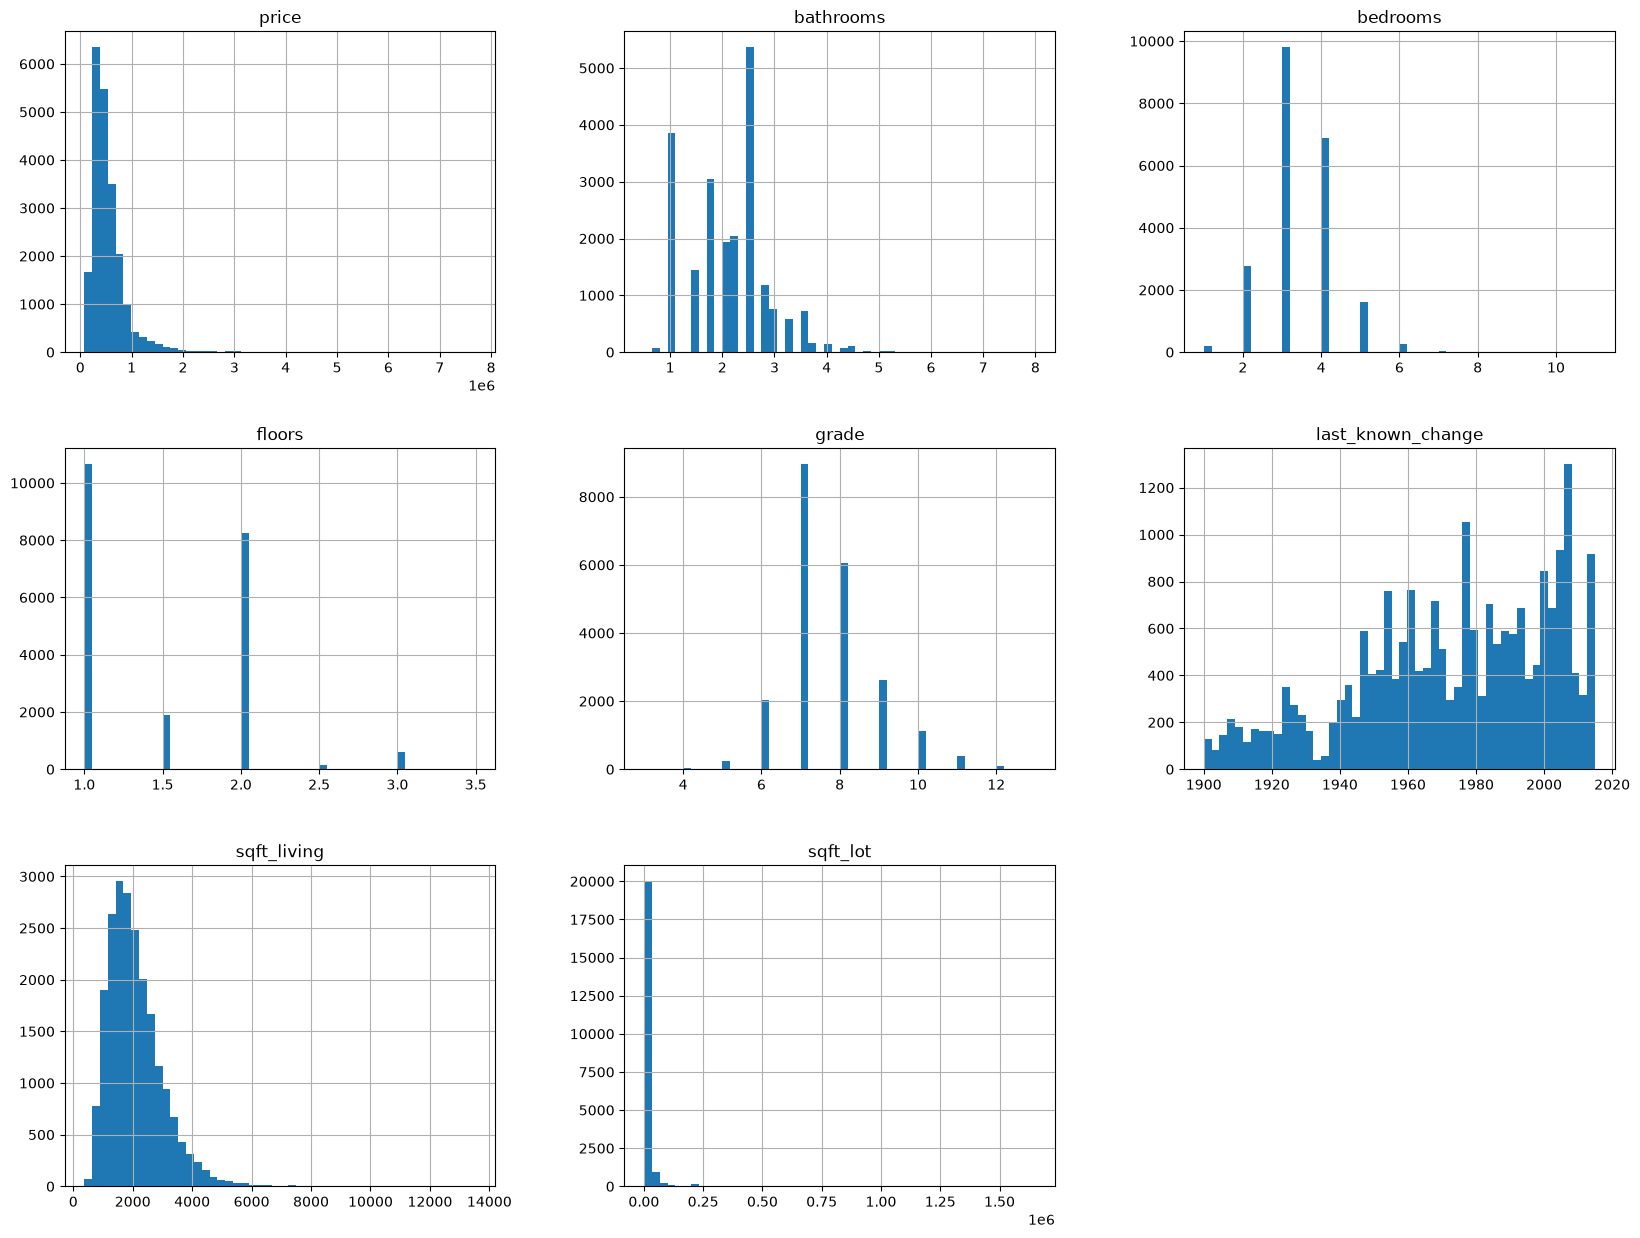

In [102]:
# Plot histograms.
kc_data[columns_histogram].hist(bins=50, figsize=(20, 15))
plt.show()

Histograms help us understand both the overall distribution and the rough shape of each variable.

Findings:
- `price` is right-skewed, with a small number of very expensive houses stretching the distribution.
- More than 5000 houses have 2.5 bathrooms. In the U.S., `.5` typically indicates a toilet room without a shower.
- Most houses have between 2 and 5 bedrooms, with 3 bedrooms being the most common.
- Most houses have only one floor.
- Most houses have a grade between 6 and 10 on the 1 to 13 scale.
- Very few houses were built or renovated between 1930 and 1940. Construction increases noticeably after that period.
- `sqft_living` is also somewhat right-skewed.
- Extreme lot sizes distort the lot-area histogram, which makes the main distribution harder to see.

Another useful view is the box plot, which displays the same summary statistics graphically.



In [103]:
# Plot box plots.
fig = px.box(kc_data, y="price", labels={"price": "House Price in $"})
fig.show()

If we try the box plot with different columns, we can clearly see outliers in several variables.  

Outliers matter because they can strongly affect model quality, but they should not be removed automatically.

For the property with 33 bedrooms, the value was implausible enough to treat it as an error and remove the row.
By contrast, very expensive houses are rare but believable in the Seattle area, so we keep them.

This is a good example of why domain knowledge matters: **an unusual value is not always a wrong value**.



It is also useful to inspect relationships between variables.
A pair plot gives a quick overview by plotting each variable against the others and showing the univariate distributions on the diagonal.

When reading the pair plot, we are especially interested in possible relationships such as:
- how price changes as living area increases
- whether better grades are associated with higher prices
- whether some features appear to move together



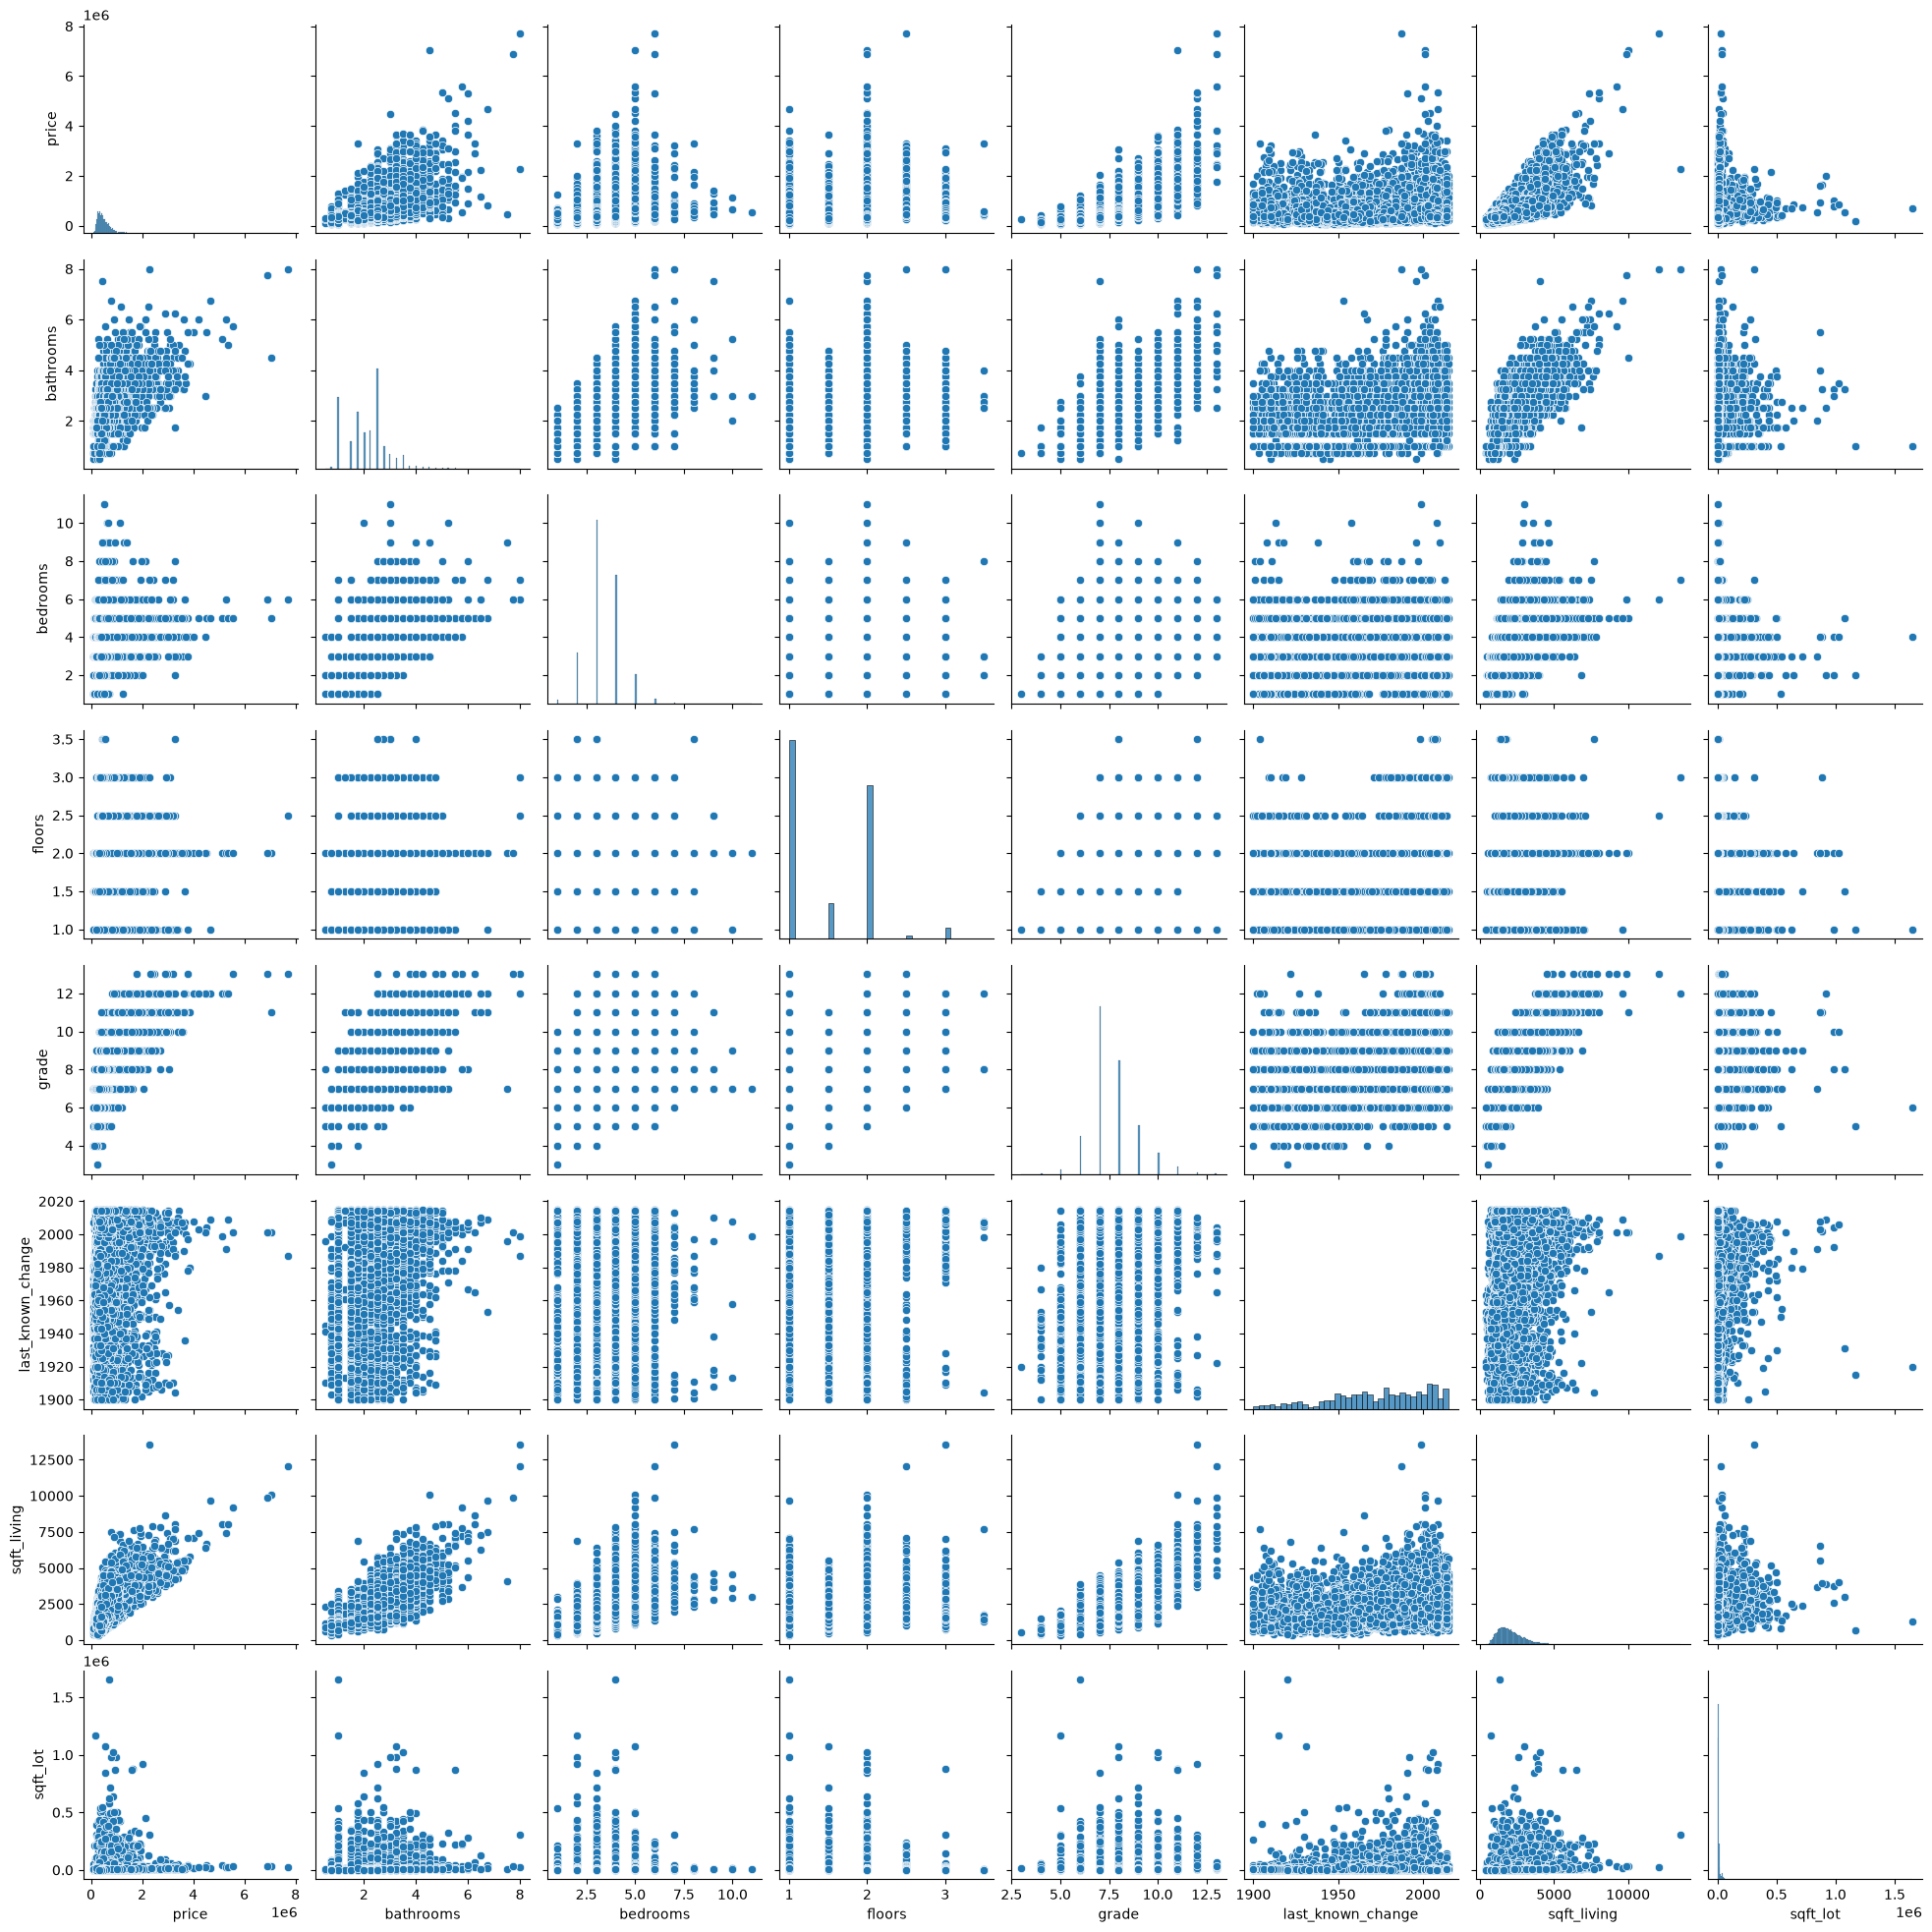

In [104]:
# Plot scatterplots.
sns.pairplot(kc_data[columns_histogram]);

A heatmap provides another view of correlation, this time by summarizing the linear relationship between every pair of variables.

Strong red tones indicate positive correlation, while strong blue tones indicate negative correlation. For example:
- larger living area is often associated with higher price
- greater distance from the wealth center may be associated with lower price

**Correlation does not prove causation**, but it helps us identify promising variables for a linear model.



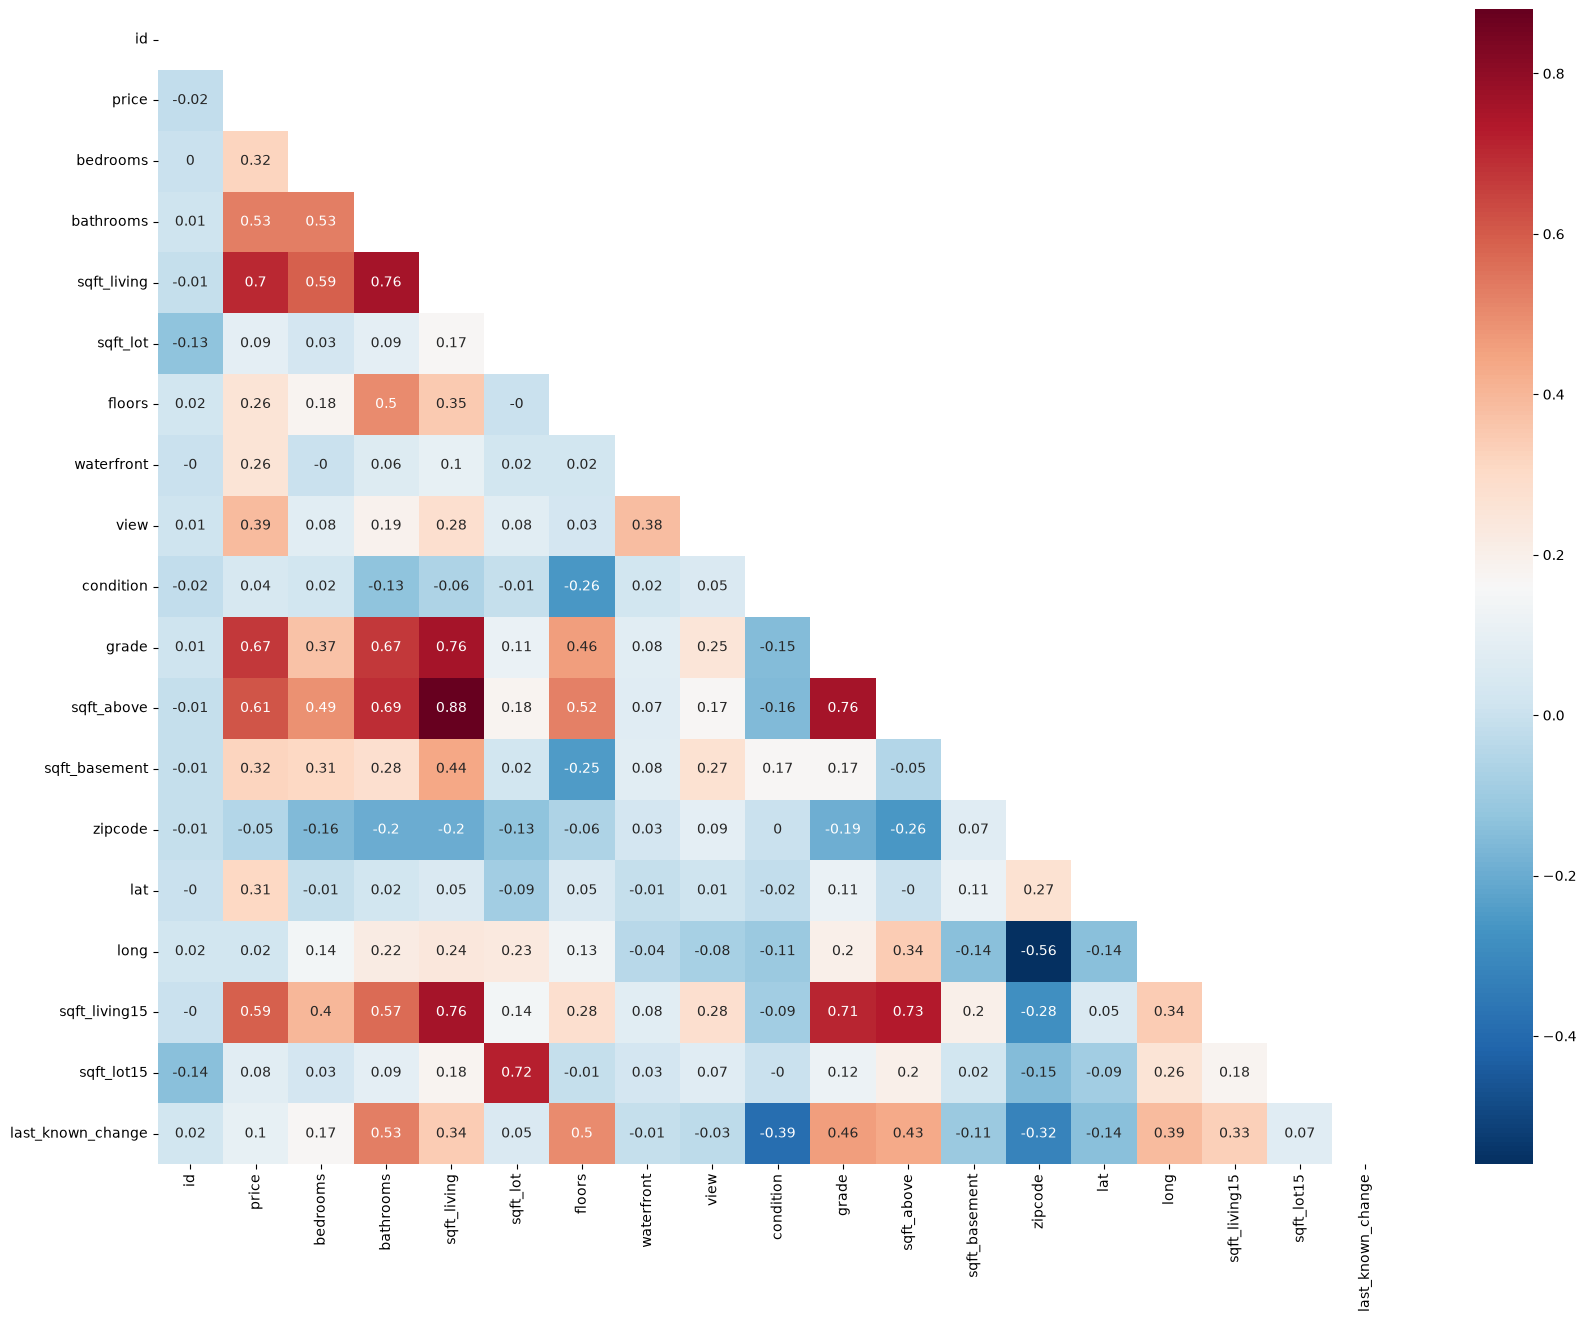

In [105]:
# Heatmap of the Pearson correlation coefficients
numeric_kc_data = kc_data.select_dtypes(include=["number"])
mask = np.triu(numeric_kc_data.corr())
plt.figure(figsize=(20, 15))
ax = sns.heatmap(round(numeric_kc_data.corr(), 2), annot=True, mask=mask, cmap="RdBu_r")

## Feature Engineering

Feature engineering means creating new variables that may explain the target more clearly or improve predictive performance.

In this project, we first adjust the target variable itself. Buyers often think in terms of value for money rather than total price alone, so we use **price per square foot of living space** as the quantity to model.



In [106]:
# Create a variable for price per square foot of living space.
kc_data["sqft_price"] = (
    kc_data.price / (kc_data.sqft_living + kc_data.sqft_lot)
).round(2)

**Distance to the center of wealth**

One possible explanatory feature is the distance to a highly desirable area. As a simple proxy, we use Bill Gates' residence in Medina, on Lake Washington, as a rough "center of wealth".
According to Wikipedia, the estate has an estimated value of about **US$147.5 million**.

<center><a href="https://en.wikipedia.org/wiki/Bill_Gates%27s_house#/media/File:Residence_of_Bill_Gates.jpg"><img src="https://upload.wikimedia.org/wikipedia/commons/2/26/Residence_of_Bill_Gates.jpg" alt="Bill Gates residence" width="700"></a></center>

To create this feature, we compute the geographic distance between each house and that reference point.
We correct longitude by `cos(lat)` because the physical distance represented by one degree of longitude depends on latitude.
This gives us a more realistic distance in kilometers.


In [107]:
kc_data[kc_data["sqft_price"] == kc_data["sqft_price"].max()]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15,sqft_lot15,last_known_change,sqft_price
3449,2559950110,4/22/2015,1230000.0,2,2.5,2470,609,3.0,0.0,0.0,...,11,1910,560,98112,47.6182,-122.312,2440,1229,2011,399.48


In [108]:
kc_data[kc_data["price"] == kc_data["price"].max()]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15,sqft_lot15,last_known_change,sqft_price
7245,6762700020,10/13/2014,7700000.0,6,8.0,12050,27600,2.5,0.0,3.0,...,13,8570,3480,98102,47.6298,-122.323,3940,8800,1987,194.2


In [109]:
# Absolute difference in latitude between the center and the property.
kc_data["delta_lat"] = np.absolute(47.62774 - kc_data["lat"])
# Absolute difference in longitude between the center and the property.
kc_data["delta_long"] = np.absolute(-122.24194 - kc_data["long"])
# Distance between the center and the property.
kc_data["center_distance"] = (
    (
        (kc_data["delta_long"] * np.cos(np.radians(47.6219))) ** 2
        + kc_data["delta_lat"] ** 2
    )
    ** (1 / 2)
    * 2
    * np.pi
    * 6378
    / 360
)

Now let us check whether this assumption is supported by the data: are properties closer to the wealth center generally more expensive?



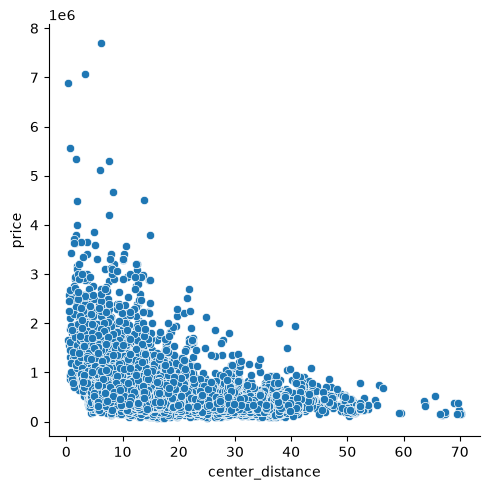

In [110]:
# Scatter plot: price versus distance to the center.
sns.relplot(y="price", x="center_distance", data=kc_data);

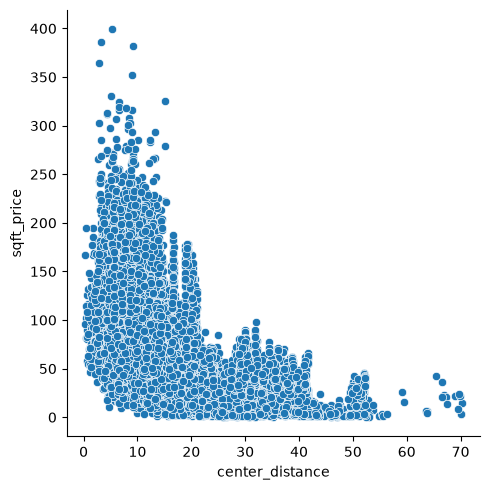

In [111]:
# Scatter plot: price per square foot versus distance to the center.
sns.relplot(y="sqft_price", x="center_distance", data=kc_data);

The charts support our hypothesis: price tends to decrease as distance from the wealth center increases.
The price-performance ratio also improves with distance, because the price per square foot tends to fall.

We can also plot all houses on a map of King County.
The color indicates how close each house is to the wealth center, while the marker size reflects sale price.



In [112]:
fig = px.scatter_map(
    kc_data,
    lat="lat",
    lon="long",
    hover_name="id",
    hover_data=["sqft_price", "sqft_living", "zipcode", "floors"],
    size="sqft_price",
    color="center_distance",
    color_continuous_scale=["green", "yellow", "red"],
    color_discrete_sequence=["fuchsia"],
    zoom=7.7,
    height=400,
)
fig.update_layout(map_style="open-street-map")
fig.update_layout(margin={"r": 0, "t": 0, "l": 0, "b": 0})
fig.show()

**Distance to the waterfront**

Next, we construct a rough measure of water proximity.
We first extract all houses with `waterfront = 1` into a list called `water_list`. Then, for each house in the dataset, we calculate the minimum distance to any house in that list.

This is only an approximation, because waterfront houses do not describe the entire shoreline perfectly, but it still gives us a useful proxy for how close a property is to the water.



In [113]:
# This helper function calculates the distance between one house and a reference location.
def dist(long, lat, ref_long, ref_lat):
    """dist computes the distance in km to a reference location.
    Input: long and lat of the location of interest and ref_long and ref_lat
    as the long and lat of the reference location"""
    delta_long = long - ref_long
    delta_lat = lat - ref_lat
    delta_long_corr = delta_long * np.cos(np.radians(ref_lat))
    return (
        ((delta_long_corr) ** 2 + (delta_lat) ** 2) ** (1 / 2) * 2 * np.pi * 6378 / 360
    )

In [114]:
# Add all waterfront houses to the reference list.
water_list = kc_data.query("waterfront == 1")
water_list.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,zipcode,lat,long,sqft_living15,sqft_lot15,last_known_change,sqft_price,delta_lat,delta_long,center_distance
49,822039084,3/11/2015,1350000.0,3,2.50,2753,65005,1.0,1.0,2.0,...,98070,47.4041,-122.451,2680,72513,1953,19.92,0.22364,0.20906,29.424514
230,8096000060,4/13/2015,655000.0,2,1.75,1450,15798,2.0,1.0,4.0,...,98166,47.4497,-122.375,2030,13193,1978,37.98,0.17804,0.13306,22.191410
246,2025069065,9/29/2014,2400000.0,4,2.50,3650,8354,1.0,1.0,4.0,...,98074,47.6338,-122.072,3120,18841,2000,199.93,0.00606,0.16994,12.768424
264,2123039032,10/27/2014,369900.0,1,0.75,760,10079,1.0,1.0,4.0,...,98070,47.4683,-122.438,1230,14267,1936,34.13,0.15944,0.19606,23.052131
300,3225069065,6/24/2014,3080000.0,4,5.00,4550,18641,1.0,1.0,4.0,...,98074,47.6053,-122.077,4550,19508,2002,132.81,0.02244,0.16494,12.625028


In [115]:
water_distance = []
# For each row, calculate the distance to the nearest waterfront house.
for idx in kc_data.index:
    ref_list = []
    for x, y in zip(list(water_list["long"]), list(water_list["lat"])):
        ref_list.append(dist(kc_data["long"][idx], kc_data["lat"][idx], x, y).min())
    water_distance.append(min(ref_list))

In [116]:
# Create a new column from the previously computed list.
kc_data["water_distance"] = water_distance

In [117]:
# Create a new column from the previously computed list.
kc_data.describe().round(2)

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,lat,long,sqft_living15,sqft_lot15,last_known_change,sqft_price,delta_lat,delta_long,center_distance,water_distance
count,2.159600e+04,21596.00,21596.00,21596.00,21596.00,21596.00,21596.00,21596.00,21596.00,21596.00,...,21596.00,21596.00,21596.00,21596.00,21596.00,21596.00,21596.00,21596.00,21596.00,21596.00
mean,4.580575e+09,540291.96,3.37,2.12,2080.34,15099.83,1.49,0.01,0.23,3.41,...,47.56,-122.21,1986.65,12758.66,1972.95,59.73,0.12,0.11,17.53,5.54
std,2.876764e+09,367376.02,0.90,0.77,918.12,41413.55,0.54,0.08,0.76,0.65,...,0.14,0.14,685.23,27275.02,28.95,45.62,0.10,0.09,10.15,5.93
min,1.000102e+06,78000.00,1.00,0.50,370.00,520.00,1.00,0.00,0.00,1.00,...,47.16,-122.52,399.00,651.00,1900.00,0.16,0.00,0.00,0.34,0.00
25%,2.123049e+09,322000.00,3.00,1.75,1430.00,5040.00,1.00,0.00,0.00,3.00,...,47.47,-122.33,1490.00,5100.00,1954.00,28.14,0.05,0.06,10.33,1.91
50%,3.904930e+09,450000.00,3.00,2.25,1910.00,7619.00,1.50,0.00,0.00,3.00,...,47.57,-122.23,1840.00,7620.00,1977.00,46.88,0.09,0.10,14.46,3.42
75%,7.308950e+09,645000.00,4.00,2.50,2550.00,10685.50,2.00,0.00,0.00,4.00,...,47.68,-122.12,2360.00,10083.00,1999.00,78.02,0.16,0.15,22.54,6.36
max,9.900000e+09,7700000.00,11.00,8.00,13540.00,1651359.00,3.50,1.00,4.00,5.00,...,47.78,-121.32,6210.00,871200.00,2015.00,399.48,0.47,0.93,70.19,57.43


The new variables are appended to the dataset.
On average, the houses in our dataset are about 17 km from the wealth center and almost 19 km from a house with a waterfront view. The house farthest from the wealth center is roughly 70 km away.

Again, we can test whether proximity to the water appears to influence price.



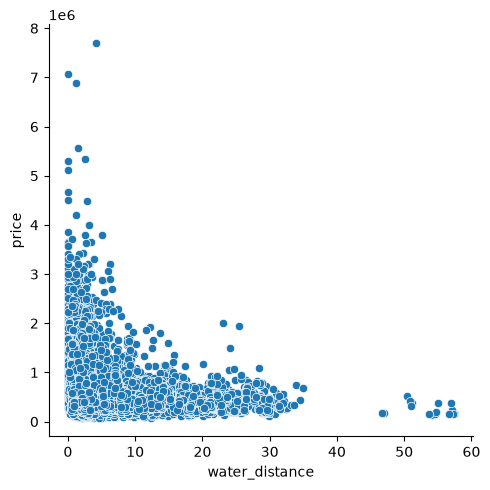

In [118]:
sns.relplot(y="price", x="water_distance", data=kc_data);

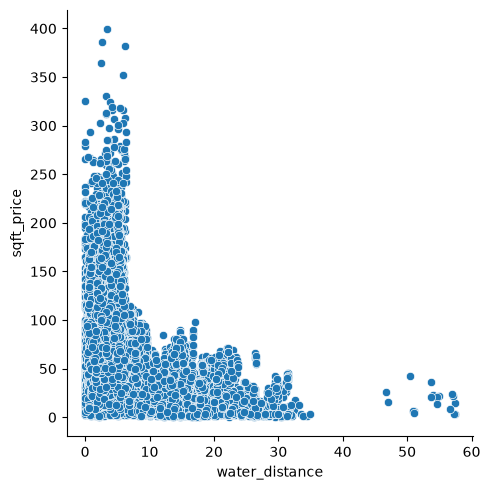

In [119]:
sns.relplot(y="sqft_price", x="water_distance", data=kc_data);

These charts again support our hypothesis: price tends to decrease as distance from the water increases, and the price per square foot also falls.

The map offers an additional sanity check. Houses close to the water should have small `water_distance` values, and that is exactly what we see.



In [120]:
fig = px.scatter_map(
    kc_data.query("water_distance <= 5"),
    lat="lat",
    lon="long",
    hover_name="id",
    hover_data=["sqft_price", "sqft_living", "zipcode", "floors"],
    size="sqft_price",
    color="water_distance",
    color_continuous_scale=["green", "yellow", "red"],
    color_discrete_sequence=["fuchsia"],
    zoom=8.4,
    height=400,
)
fig.update_layout(map_style="open-street-map")
fig.update_layout(margin={"r": 0, "t": 0, "l": 0, "b": 0})
fig.show()

# Modeling

Now that we understand the data better, we can start building a model to estimate the value of new houses.

Our goal is to predict a house price using information that would already be known before the sale.
Because we do not have truly future observations yet, we simulate that situation by splitting the existing dataset into a training set and a test set.

The training set is used to fit the model.
The test set acts like unseen future data and helps us estimate how well the model generalizes.

To create this split, we use scikit-learn's **train/test split**.
We specify:
- the input variables `X`
- the target variable `y`
- the proportion reserved for testing
- a `random_state` for reproducibility

The `random_state` matters because the rows are shuffled before the split. Without shuffling, an unlucky ordering of the data could bias the evaluation.
Using a fixed seed ensures that we can reproduce the same split later.

Before splitting, we also remove columns that would create data leakage or provide no useful predictive signal.

```mermaid
flowchart LR
    A[Select features X and target y] --> B[Remove leakage-prone columns]
    B --> C[Train/test split]
    C --> D[Train model]
    D --> E[Evaluate on test set]
    E --> F[Tune and regularize]
    F --> G[Inspect errors]
    G --> H[Save final model]
```



In [121]:
# Remove columns that would cause data leakage or add no predictive value.
drop_lst = [
    "price",
    "sqft_price",
    "date",
    "delta_lat",
    "delta_long",
]

In [122]:
# Keep all remaining variables as candidate features.
all_features = [x for x in kc_data.columns if x not in drop_lst]

In [123]:
# `X` contains the descriptive variables defined above.
X = kc_data[all_features]

In [162]:
X.columns

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'zipcode', 'lat', 'long', 'sqft_living15',
       'sqft_lot15', 'last_known_change', 'center_distance', 'water_distance'],
      dtype='str')

In [124]:
# Define `y` as the target variable.
y = kc_data.price

In [125]:
# Split the data into training and test sets. We reserve 30% for evaluation.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [126]:
# Inspect the size of each split.
print("X_train (features for the model to learn from): ", X_train.shape)
print("y_train (labels for the model to learn from): ", y_train.shape)
print("X_test (features to test the model's accuracy against): ", X_test.shape)
print("y_test (labels to test the model's accuracy with): ", y_test.shape)

X_train (features for the model to learn from):  (15117, 20)
y_train (labels for the model to learn from):  (15117,)
X_test (features to test the model's accuracy against):  (6479, 20)
y_test (labels to test the model's accuracy with):  (6479,)


In [127]:
# The training data is now shuffled rather than sorted by index.
X_train.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15,sqft_lot15,last_known_change,center_distance,water_distance
3372,1770000490,2,1.75,1060,16470,1.0,0.0,0.0,3,7,1060,0,98072,47.7409,-122.089,1790,16748,1977,17.039745,10.681894
753,8682300890,2,2.50,2380,6600,1.0,0.0,0.0,3,8,2380,0,98053,47.7170,-122.020,1870,6600,2010,19.391272,9.342139
1418,8073000550,4,3.75,3190,17186,2.0,1.0,4.0,3,10,3190,0,98178,47.5115,-122.246,2290,13496,1999,12.943085,0.000000
8178,7212680850,3,2.50,1730,6930,2.0,0.0,0.0,3,8,1730,0,98003,47.2621,-122.308,1780,6930,1994,41.002661,9.194998
2254,8880600070,4,2.00,1870,8750,1.0,0.0,2.0,3,7,1870,0,98022,47.1985,-122.001,1770,8207,1977,51.087178,29.623377


After the split, we can start modeling.
We continue with scikit-learn, where the overall workflow is usually the same:

- import the algorithm
- instantiate the model with its hyperparameters
- choose the feature columns
- fit the model with `.fit(X_train, y_train)`
- evaluate it on the test data

This repeated pattern makes it easy to compare several models in a structured way.



In [128]:
# Instantiate the model.
model_lin_reg = LinearRegression()

Next, we decide which variables to pass to the model.
We begin with a very simple baseline that uses only one predictor: the house `grade`.



In [129]:
# Select the variables passed to the model.
variables = ["grade"]

In [130]:
# Train the model.
model_lin_reg.fit(X_train[variables], y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[211503.07]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['grade']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.078e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [131]:
# Evaluate how well the model performs on the test data.
print(
    "Adj. R^2:",
    round(
        1
        - (1 - model_lin_reg.score(X_test[variables], y_test))
        * (X_test.shape[0] - 1)
        / (X_test.shape[0] - len(variables) - 1),
        2,
    ),
)

Adj. R^2: 0.43


**R²** measures the proportion of variance in the target variable that is explained by the model.
**Adjusted R²** is a related metric that also accounts for the number of predictors, which makes it more useful when comparing models of different complexity.

Interpretation:
- `1.0` means the model explains all observed variance
- `0.0` means the model explains none of it

In our case, using only `grade` explains about **43%** of the variance in price per square foot on the test set.
That is a useful start, but it suggests that additional variables may improve the model.

Let us inspect the available features again.



In [132]:
# Show the names of the variables in the dataset.
X_train.columns

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'zipcode', 'lat', 'long', 'sqft_living15',
       'sqft_lot15', 'last_known_change', 'center_distance', 'water_distance'],
      dtype='str')

We can use more features to predict price per square foot.
The age of the house may also matter, so next we try a linear regression that includes both `grade` and age-related information.



In [133]:
# Instantiate the model.
model_lin_reg = LinearRegression()

In [134]:
# Select the variables passed to the model.
variables = ["grade", "last_known_change"]

In [135]:
# Train the model.
model_lin_reg.fit(X_train[variables], y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[250617.39, -3456.69]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['grade','last_known_change']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.442e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [166]:
X_train.columns

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'zipcode', 'lat', 'long', 'sqft_living15',
       'sqft_lot15', 'last_known_change', 'center_distance', 'water_distance'],
      dtype='str')

In [136]:
# Evaluate how well the model performs on the test data.
print(
    "Adj. R^2:",
    round(
        1
        - (1 - model_lin_reg.score(X_test[variables], y_test))
        * (X_test.shape[0] - 1)
        / (X_test.shape[0] - len(variables) - 1),
        2,
    ),
)

Adj. R^2: 0.48


With this additional variable, the model explains about **48%** of the variance in price per square foot.



So far, we have only modeled linear relationships between the predictors and price.
However, some effects may be curved rather than straight.

One simple way to capture that is to add squared terms. Instead of fitting only:

$price = b \cdot grade + c$

we can also fit:

$price = a \cdot grade^{2} + b \cdot grade + c$

This is another form of feature engineering. We will apply it to the dataset and see whether the richer representation improves performance.



In [137]:
# Create only second-order polynomial features (^2).
poly = PolynomialFeatures(2)

In [138]:
# Create copies of the training and test data.
X_train_poly = X_train.copy()
X_test_poly = X_test.copy()

# Drop the `id` column.
X_train_poly = X_train_poly.drop(columns=["id"])
X_test_poly = X_test_poly.drop(columns=["id"])

In [139]:
# Create transformed variables with `poly`.
X_train_sq = poly.fit_transform(X_train_poly)

# Apply the same transformation to the test data.
X_test_sq = poly.transform(X_test_poly)

In [140]:
# Instantiate the model.
model_lin_reg = LinearRegression()

In [141]:
# Train the model with the squared features.
model_lin_reg.fit(X_train_sq, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](210,)","[ 0.,-0., 0.,..., 0., 0., 0.]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.664e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,210
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(37)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](210,)","[4.26e+12,1.32e+12,3.54e+11,...,4.42e-04,4.41e-04,4.02e-04]"


In [142]:
# Evaluate how well the model performs on the test data.
print(
    "Adj. R^2:",
    round(
        1
        - (1 - model_lin_reg.score(X_test_sq, y_test))
        * (X_test_sq.shape[0] - 1)
        / (X_test_sq.shape[0] - X_test_sq.shape[1] - 1),
        2,
    ),
)

Adj. R^2: 0.75


Adding squared features improved the model a little further.



Adjusted R² gives us one useful summary of model quality, but it is also important to inspect the errors directly.
A **residual analysis** can reveal systematic problems that a single score might hide.  

For easier interpretation, we calculate the percentage difference between the predicted and true prices.



In [164]:
# Error analysis
# To inspect the model errors more closely, create a new DataFrame with the
# columns `price` (the true value), `lat`, and `long`.
y_predictions = model_lin_reg.predict(X_test_sq)
df_error = pd.DataFrame(y_test)
df_error["latitude"] = X_test["lat"]
df_error["longitude"] = X_test["long"]
df_error["id"] = X_test["id"]
df_error.head(2)

,price,latitude,longitude,id
3686,132500.0,47.5030,-122.356,6303401050
10247,415000.0,47.6966,-122.324,1995200200


In [165]:
X_test_sq

array([[1.00000000e+00, 3.00000000e+00, 7.50000000e-01, ...,
        2.66050475e+02, 2.69189522e+01, 2.72365607e+00],
       [1.00000000e+00, 3.00000000e+00, 1.00000000e+00, ...,
        9.66648936e+01, 3.77490199e+01, 1.47415308e+01],
       [1.00000000e+00, 4.00000000e+00, 2.25000000e+00, ...,
        1.65935940e+03, 1.04016315e+03, 6.52022322e+02],
       ...,
       [1.00000000e+00, 4.00000000e+00, 2.75000000e+00, ...,
        1.63965992e+02, 7.83293717e+00, 3.74192867e-01],
       [1.00000000e+00, 3.00000000e+00, 1.75000000e+00, ...,
        1.43202325e+02, 5.32838048e+01, 1.98262412e+01],
       [1.00000000e+00, 5.00000000e+00, 3.50000000e+00, ...,
        2.16118225e+02, 4.73663889e+01, 1.03812383e+01]],
      shape=(6479, 210))

In [144]:
# Reset the index before adding the predicted price as a new column.
df_error.reset_index(inplace=True, drop=True)
df_error.head(2)

,price,latitude,longitude,id
0,132500.0,47.5030,-122.356,6303401050
1,415000.0,47.6966,-122.324,1995200200


In [145]:
# Add the predicted price and calculate the difference.
df_error["price_prediction"] = y_predictions.round(2)
df_error["price_difference"] = (df_error["price_prediction"] - df_error["price"]).round(
    2
)
df_error["price_difference_percent"] = (
    (df_error["price_difference"] / df_error["price"]) * 100
).round(2)
df_error.head(2)

,price,latitude,longitude,id,price_prediction,price_difference,price_difference_percent
0,132500.0,47.5030,-122.356,6303401050,183826.08,51326.08,38.74
1,415000.0,47.6966,-122.324,1995200200,382829.44,-32170.56,-7.75


In [146]:
fig = px.scatter_map(
    df_error,
    lat="latitude",
    lon="longitude",
    hover_data=["price", "price_prediction", "id"],
    color="price_difference_percent",
    color_continuous_scale=["green", "yellow", "red"],
    zoom=7.7,
    height=400,
)
fig.update_layout(map_style="open-street-map")
fig.update_layout(margin={"r": 0, "t": 0, "l": 0, "b": 0})
fig.show()

We can already see a few strong outliers in the residual plot, so it is worth inspecting the largest one more closely.



In [147]:
df_error[
    df_error["price_difference_percent"] == df_error["price_difference_percent"].max()
]

,price,latitude,longitude,id,price_prediction,price_difference,price_difference_percent
2125,169317.0,47.6248,-122.301,5016003230,716736.32,547419.32,323.31


In [148]:
X_test[X_test["id"] == 9272202260]

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15,sqft_lot15,last_known_change,center_distance,water_distance
18318,9272202260,3,1.0,1200,7000,2.0,0.0,0.0,1,7,1200,0,98116,47.5883,-122.384,3290,6000,1908,11.527542,3.49912


Let us inspect these houses in more detail.
King County provides a helpful property lookup tool on [this page](https://localscape.property/#kingcountyassessor/My-Property), where you can search by parcel ID.

To inspect the outlier:
- change the selector in the top-left corner from `Address` to `Parcel ID`
- enter the `id` of the outlier

Under **Basic Property Characteristics** and in the **Aerial Images** view, we can see that there is no longer a house on the property. That explains why our model estimated a much higher sale value than the actual transaction suggests.



## Regularization and Hyperparameter Tuning

After adding squared features, the model has many more inputs.
Some of them may contribute useful signal, while others mainly capture noise.
If a model learns noise instead of general patterns, it becomes **overfitted**.

**Regularization** helps control this problem by shrinking coefficients and, in some cases, pushing some of them all the way to zero.
That allows the model to keep the more informative variables while reducing reliance on weaker ones.

Here we use [ElasticNet](https://scikit-learn.org/stable/modules/linear_model.html#elastic-net), which combines L1 and L2 regularization.

Polynomial features have very different scales. A [Pipeline](https://scikit-learn.org/stable/modules/compose.html#pipeline) applies polynomial expansion and [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) inside each training fold to prevent validation-data leakage and help convergence. Supply the original feature columns without the identifier, not the already expanded matrix.

The compact grid keeps both penalties active; pure L2 regularization is better handled by Ridge. Five-fold validation compares 45 fits using training data only. The held-out test set is reserved for final evaluation.
A [TransformedTargetRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html) also standardizes training prices within each fold, making the regularization grid meaningful on a unit-scale target. Predictions are automatically converted back to dollars.

To find a good amount of regularization, we test multiple hyperparameter values and compare the results with [GridSearch](https://scikit-learn.org/stable/modules/grid_search.html#grid-search) and [cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation).



In [149]:
# Specify the hyperparameters to tune.
# `alpha` controls the amount of regularization.
param_grid = {
    "model__regressor__alpha": [0.01, 0.1, 1],
    "model__regressor__l1_ratio": [0.2, 0.5, 0.8],
}

# Keep preprocessing with the estimator for validation and inference.
elastic_pipeline = Pipeline(
    [
        ("polynomial", PolynomialFeatures(2, include_bias=False)),
        ("scaler", StandardScaler()),
        (
            "model",
            TransformedTargetRegressor(
                regressor=ElasticNet(max_iter=5000, tol=1e-4, precompute=True),
                transformer=StandardScaler(),
            ),
        ),
    ]
)

# Pass the model to a parameter grid with 5-fold cross-validation.
elastic_cv = GridSearchCV(
    elastic_pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    verbose=2,
    n_jobs=1,
    error_score="raise",
)

# Train and optimize the model with grid search.
elastic_cv.fit(X_train_poly, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END model__regressor__alpha=0.01, model__regressor__l1_ratio=0.2; total time=   0.0s
[CV] END model__regressor__alpha=0.01, model__regressor__l1_ratio=0.2; total time=   0.0s
[CV] END model__regressor__alpha=0.01, model__regressor__l1_ratio=0.2; total time=   0.0s
[CV] END model__regressor__alpha=0.01, model__regressor__l1_ratio=0.2; total time=   0.0s
[CV] END model__regressor__alpha=0.01, model__regressor__l1_ratio=0.2; total time=   0.0s
[CV] END model__regressor__alpha=0.01, model__regressor__l1_ratio=0.5; total time=   0.0s
[CV] END model__regressor__alpha=0.01, model__regressor__l1_ratio=0.5; total time=   0.0s
[CV] END model__regressor__alpha=0.01, model__regressor__l1_ratio=0.5; total time=   0.0s
[CV] END model__regressor__alpha=0.01, model__regressor__l1_ratio=0.5; total time=   0.0s
[CV] END model__regressor__alpha=0.01, model__regressor__l1_ratio=0.5; total time=   0.0s
[CV] END model__regressor__alpha=0.01, m

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...rdScaler()))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__regressor__alpha': [0.01, 0.1, ...], 'model__regressor__l1_ratio': [0.2, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric 

In [150]:
# Display the best parameters found by the grid search.
elastic_cv.best_params_

{'model__regressor__alpha': 0.01, 'model__regressor__l1_ratio': 0.2}

In [151]:
# GridSearchCV already refits the winning pipeline on all training rows.
elastic = elastic_cv.best_estimator_

In [152]:
# Evaluate how well the model performs on the test data.
print("Test R^2:", round(elastic.score(X_test_poly, y_test), 3))

Test R^2: 0.844


Compare held-out R^2 with the earlier models; regularization does not guarantee improvement. Counting nonzero coefficients is not an exact degrees-of-freedom correction for ElasticNet, so we report ordinary R^2.  

As discussed above, regularization can set some regression coefficients to zero, effectively removing less useful variables from the model.  

The following code displays part of the learned coefficient vector. Check whether any coefficients became zero rather than assuming they did.



In [153]:
# Coefficients are in standardized feature and target units, not dollars.
elastic.named_steps["model"].regressor_.coef_[0:5]

array([-0.        , -0.        ,  0.        ,  0.00116475, -0.        ])

In [154]:
# Error analysis
# To inspect the model errors more closely, create a new DataFrame with the
# columns `price` (the true value), `lat`, and `long`.
y_predictions = elastic.predict(X_test_poly)
df_error = pd.DataFrame(y_test)
df_error["latitude"] = X_test["lat"]
df_error["longitude"] = X_test["long"]
df_error["id"] = X_test["id"]
df_error.head(2)

,price,latitude,longitude,id
3686,132500.0,47.5030,-122.356,6303401050
10247,415000.0,47.6966,-122.324,1995200200


In [155]:
# Reset the index before adding the predicted price as a new column.
df_error.reset_index(inplace=True, drop=True)
df_error.head(2)

,price,latitude,longitude,id
0,132500.0,47.5030,-122.356,6303401050
1,415000.0,47.6966,-122.324,1995200200


In [156]:
# Add the predicted price and calculate the difference.
df_error["price_prediction"] = y_predictions.round(2)
df_error["price_difference"] = (df_error["price_prediction"] - df_error["price"]).round(
    2
)
df_error["price_difference_percent"] = (
    (df_error["price_difference"] / df_error["price"]) * 100
).round(2)
df_error.head(2)

,price,latitude,longitude,id,price_prediction,price_difference,price_difference_percent
0,132500.0,47.5030,-122.356,6303401050,221701.18,89201.18,67.32
1,415000.0,47.6966,-122.324,1995200200,411290.09,-3709.91,-0.89


In [157]:
fig = px.scatter_map(
    df_error,
    lat="latitude",
    lon="longitude",
    hover_data=["price", "price_prediction", "id"],
    color="price_difference_percent",
    color_continuous_scale=["green", "yellow", "red"],
    zoom=7.7,
    height=400,
)
fig.update_layout(map_style="open-street-map")
fig.update_layout(margin={"r": 0, "t": 0, "l": 0, "b": 0})
fig.show()

In [158]:
df_error[
    df_error["price_difference_percent"] == df_error["price_difference_percent"].max()
]

,price,latitude,longitude,id,price_prediction,price_difference,price_difference_percent
3344,150000.0,47.7112,-121.315,1437500015,599743.09,449743.09,299.83


In [159]:
X_test[X_test["id"] == 5111400086]

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15,sqft_lot15,last_known_change,center_distance,water_distance
17183,5111400086,3,1.0,1250,53143,1.0,0.0,0.0,5,6,1250,0,98038,47.4235,-122.051,1820,217800,1945,26.872648,14.812078


Let us take a closer look at this house on [this page](https://localscape.property/#kingcountyassessor/My-Property).

This house sold in 2018 for $295,000. King County appraisal data also reports historical values, and under **Historical Value** we can see that the **Total Assessed Value** in 2014 was $212,000.
That means the sale price was still unusually low relative to the broader context, which helps explain why it stands out so strongly in the residual analysis.



## Save the Model

We have now trained a model that can predict house prices in King County.
The final step is to save the trained pipeline with [skops](https://skops.readthedocs.io/en/stable/modules/classes.html#module-skops.io). Polynomial expansion and scaling are included: inference expects the original training feature columns in the same order, without the identifier.

If you want to explore the optional application stretch goal, see [bonus_solution/](./bonus_solution/). It contains a small working FastAPI + Postgres + Docker example that is meant as a reference, not a required solution path.



In [160]:
import os

import skops.io as sio

# Create the directory if it does not already exist.
os.makedirs("model", exist_ok=True)

with open("model/model.bin", "wb") as f_out:
    sio.dump(elastic, f_out)

### Conclusion

Despite the presence of outliers, we built a model that explains roughly **83%** of the variance in the target.  

The notebook also shows an important modeling lesson: **feature engineering, nonlinear terms, and regularization can all make a meaningful difference in predictive performance**.

